# Đề tài 4 — Notebook 03: So sánh One-stage (YOLOv8n) vs Two-stage (Faster R-CNN)

**Yêu cầu nâng cao của đề bài:** *"So sánh one-stage (YOLO) với two-stage (Faster R-CNN từ torchvision) về mAP và FPS trên cùng phần cứng, cùng phép chia dữ liệu."*

**Điều kiện tiên quyết:** đã chạy xong `02_train_eval.ipynb` (cần `artifacts/best_config.json` để lấy số liệu YOLOv8n dùng so sánh).

**Nguyên tắc giữ công bằng — và những chỗ KHÔNG THỂ giữ công bằng tuyệt đối, nói rõ ngay từ đầu:**

| Điều kiện | Có giữ công bằng được không |
|---|---|
| Cùng phần cứng, cùng seed=42, cùng phép chia train/val/test | ✔ Có |
| Cùng độ phân giải đầu vào (640×640) | ✔ Có — ép `min_size=max_size=640` cho Faster R-CNN (mặc định của nó là 800/1333, khác hẳn YOLO) |
| Cùng số epoch, cùng optimizer | ✘ **Không nên** — hai kiến trúc khác hẳn nhau về động lực học. Faster R-CNN dùng backbone ResNet-50 rất sâu, đã có sẵn đặc trưng tốt từ COCO, thường hội tụ trong ít epoch hơn nhiều so với YOLO train-from-scratch-head. Siêu tham số dưới đây dựa theo khuyến nghị chính thức của torchvision (*"TorchVision Object Detection Finetuning Tutorial"*: `lr=0.005, momentum=0.9, weight_decay=0.0005`), không copy nguyên xi cấu hình của YOLOv8n — copy máy móc sẽ cho kết quả không đại diện cho khả năng thật của Faster R-CNN. |
| Cùng cách tính mAP | Gần giống — dùng `torchmetrics` (chuẩn COCO), cùng công thức toán học với cách ultralytics tính, nhưng là hai codebase độc lập nên có thể lệch vài phần nghìn do khác nhau ở chi tiết cài đặt (nội suy đường PR...). Không nên diễn giải chênh lệch dưới 0,005 là có ý nghĩa thống kê.

## 0. Thiết lập

In [1]:
import sys, os, time, json, warnings
from pathlib import Path

import torch.multiprocessing
# Sửa lỗi "Too many open files": chiến lược mặc định chia sẻ tensor giữa
# tiến trình chính và các DataLoader worker qua file descriptor, cạn dần
# sau nhiều batch/epoch. Đổi sang chia sẻ qua hệ thống file tránh cạn kiệt.
torch.multiprocessing.set_sharing_strategy('file_system')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

import config
from config import (YOLO_DIR, ARTIFACT_DIR, RUNS_DIR, CLASS_NAMES, NUM_CLASSES,
                    SEED, set_seed, describe_environment)
import exp_log
from exp_log import log_run, read_log
import frcnn_utils as fu

warnings.filterwarnings("ignore", category=UserWarning)
set_seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

env = describe_environment()
print(json.dumps(env, indent=2, ensure_ascii=False))

HAS_GPU = torch.cuda.is_available()
DEVICE = torch.device("cuda:0" if HAS_GPU else "cpu")
if not HAS_GPU:
    print("\n[CẢNH BÁO] Không thấy GPU — Faster R-CNN train trên CPU sẽ RẤT chậm "
          "(có thể hàng giờ cho vài epoch). Nên dừng lại và chạy trên máy có GPU.")

best_cfg_yolo = json.load(open(ARTIFACT_DIR / "best_config.json", encoding="utf-8"))
print("\nSố liệu YOLOv8n (từ NB02) dùng để so sánh:")
print(json.dumps(best_cfg_yolo, indent=2, ensure_ascii=False))

{
  "python": "3.10.20",
  "platform": "Linux-7.0.0-28-generic-x86_64-with-glibc2.39",
  "seed": 42,
  "torch": "2.7.1+cu126",
  "cuda_available": true,
  "gpu": "NVIDIA GeForce RTX 4090",
  "cuda": "12.6",
  "vram_gb": 23.5,
  "ultralytics": "8.3.40"
}

Số liệu YOLOv8n (từ NB02) dùng để so sánh:
{
  "weights": "/home/lablee/Documents/wm/projectdl/runs/yolov8n_640_e80/weights/best.pt",
  "imgsz": 640,
  "conf_deploy": 0.4,
  "iou_deploy": 0.4,
  "conf_eval": 0.001,
  "iou_eval": 0.7,
  "test_mAP50": 0.628917959240961,
  "test_mAP50_95": 0.41318532487749754
}


## 1. Siêu tham số — khai báo tường minh, dựa theo khuyến nghị torchvision

In [2]:
IMGSZ = best_cfg_yolo["imgsz"]   # 640 — ép Faster R-CNN dùng cùng độ phân giải với YOLO

FRCNN_HP = dict(
    epochs=15,             # Faster R-CNN hội tụ nhanh hơn nhiều nhờ backbone ResNet-50
                           # đã tiền huấn luyện sâu trên COCO — 15 epoch là đủ cho fine-tune
                           # trên bộ dữ liệu 3.501 ảnh, khác hẳn 80 epoch của YOLOv8n.
    batch_size=4,          # Faster R-CNN + FPN nặng bộ nhớ hơn YOLOv8n nhiều lần ở cùng
                           # độ phân giải -> batch phải nhỏ hơn nhiều (32 -> 4) để vừa VRAM.
    lr=0.005,              # theo đúng "TorchVision Object Detection Finetuning Tutorial"
    momentum=0.9,
    weight_decay=0.0005,
    lr_step_epoch=10,      # giảm lr sau epoch 10
    lr_gamma=0.1,
    num_workers=2,   # giảm từ 4 -> đỡ tích luỹ file descriptor qua nhiều epoch
)
print(json.dumps(FRCNN_HP, indent=2))
print(f"\nimgsz = {IMGSZ} (ép cả hai mô hình dùng chung độ phân giải này)")

{
  "epochs": 15,
  "batch_size": 4,
  "lr": 0.005,
  "momentum": 0.9,
  "weight_decay": 0.0005,
  "lr_step_epoch": 10,
  "lr_gamma": 0.1,
  "num_workers": 2
}

imgsz = 640 (ép cả hai mô hình dùng chung độ phân giải này)


## 2. Dataset & DataLoader — dùng lại đúng cây thư mục từ NB01

In [3]:
# augment=True CHỈ cho tập train — val/test phải giữ nguyên ảnh gốc, nếu không
# sẽ không còn đo được đúng năng lực mô hình trên dữ liệu thật.
train_ds = fu.YoloDetectionDataset(YOLO_DIR, "train", augment=True)
val_ds = fu.YoloDetectionDataset(YOLO_DIR, "val")
test_ds = fu.YoloDetectionDataset(YOLO_DIR, "test")
print(f"train={len(train_ds)} (augment={train_ds.augment})  "
     f"val={len(val_ds)}  test={len(test_ds)}")

g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=FRCNN_HP["batch_size"], shuffle=True,
                          num_workers=FRCNN_HP["num_workers"], collate_fn=fu.collate_fn,
                          generator=g)
val_loader = DataLoader(val_ds, batch_size=FRCNN_HP["batch_size"], shuffle=False,
                        num_workers=FRCNN_HP["num_workers"], collate_fn=fu.collate_fn)
test_loader = DataLoader(test_ds, batch_size=2, shuffle=False,
                         num_workers=0, collate_fn=fu.collate_fn)
# num_workers=0 riêng cho test_loader: vòng đánh giá chỉ chạy 1 lần (không cần
# tốc độ nạp dữ liệu song song như lúc train), và đây chính là nơi lỗi "Too many
# open files" xảy ra ở lượt chạy trước — giảm rủi ro cạn file descriptor.

# Kiểm chứng nhanh: 1 batch có đúng định dạng torchvision cần không
imgs, targets = next(iter(train_loader))
print(f"\n1 batch: {len(imgs)} ảnh, ảnh đầu shape={tuple(imgs[0].shape)}")
print(f"Nhãn ảnh đầu: {targets[0]['boxes'].shape[0]} hộp, "
     f"labels={targets[0]['labels'].tolist()[:5]}...")

train=3501 (augment=True)  val=750  test=749



1 batch: 4 ảnh, ảnh đầu shape=(3, 416, 415)
Nhãn ảnh đầu: 1 hộp, labels=[1]...


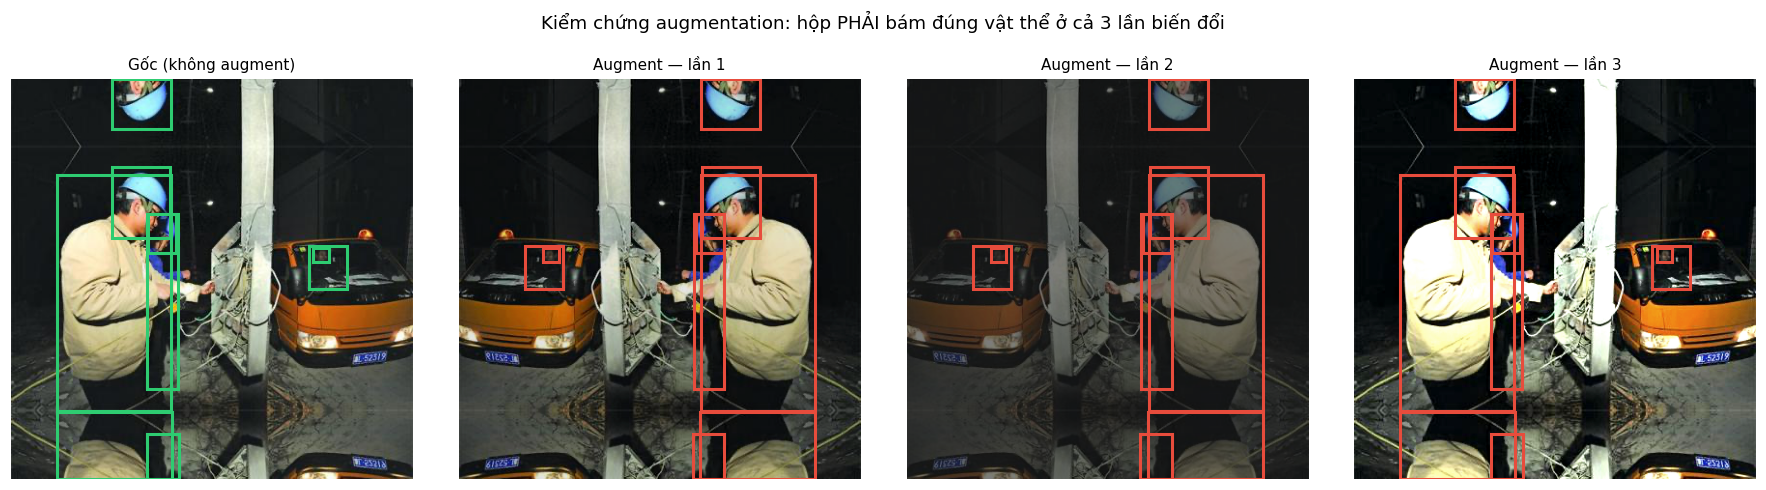

Nhìn kỹ: ảnh nào bị lật ngang thì hộp phải lật theo, vẫn ôm đúng đầu người.
Nếu hộp trôi sang chỗ khác -> logic lật hộp sai, DỪNG LẠI, không train tiếp.


In [4]:
# KIỂM CHỨNG BẮT BUỘC: lật ảnh mà quên lật hộp là lỗi âm thầm nguy hiểm nhất
# của augmentation cho bài toán detection — mô hình sẽ học nhãn sai vị trí mà
# không báo lỗi gì. Vẽ ra để xác nhận hộp vẫn bám đúng vật thể sau khi biến đổi.
import matplotlib.patches as mpatches

ds_plain = fu.YoloDetectionDataset(YOLO_DIR, "train", augment=False)
ds_aug = fu.YoloDetectionDataset(YOLO_DIR, "train", augment=True)

IDX = 7   # một ảnh bất kỳ có nhiều hộp
torch.manual_seed(0)   # để lần lật là tất định, chạy lại ra đúng hình này

fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))
img0, tgt0 = ds_plain[IDX]
axes[0].imshow(img0.permute(1, 2, 0)); axes[0].set_title("Gốc (không augment)", fontsize=10)
for b in tgt0["boxes"]:
    axes[0].add_patch(mpatches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                         fill=False, edgecolor="#2ecc71", lw=2))
for k in range(1, 4):
    img, tgt = ds_aug[IDX]
    axes[k].imshow(img.permute(1, 2, 0))
    axes[k].set_title(f"Augment — lần {k}", fontsize=10)
    for b in tgt["boxes"]:
        axes[k].add_patch(mpatches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                             fill=False, edgecolor="#e74c3c", lw=2))
for ax in axes:
    ax.axis("off")
fig.suptitle("Kiểm chứng augmentation: hộp PHẢI bám đúng vật thể ở cả 3 lần biến đổi",
             fontsize=12)
plt.savefig(ARTIFACT_DIR / "fig16_frcnn_augment_check.png", dpi=150, bbox_inches="tight")
plt.show()
print("Nhìn kỹ: ảnh nào bị lật ngang thì hộp phải lật theo, vẫn ôm đúng đầu người.")
print("Nếu hộp trôi sang chỗ khác -> logic lật hộp sai, DỪNG LẠI, không train tiếp.")

## 3. Huấn luyện

In [5]:
# Huấn luyện Faster R-CNN với tăng cường dữ liệu — cùng điều kiện với YOLOv8n,
# để phép so sánh ở §6 là cùng một thang đo.
FORCE_RETRAIN_FRCNN = False
CKPT_PATH = RUNS_DIR / "faster_rcnn" / "best_aug.pt"
HIST_PATH = RUNS_DIR / "faster_rcnn" / "history_aug.csv"
CKPT_PATH.parent.mkdir(parents=True, exist_ok=True)

model = fu.build_faster_rcnn(NUM_CLASSES, imgsz=IMGSZ).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
N_PARAMS_YOLO = 3_011_433   # đã in ra ở NB02 §2 ("Số tham số: 3011433")
print(f"Số tham số Faster R-CNN : {n_params:,}")
print(f"Số tham số YOLOv8n (NB02): {N_PARAMS_YOLO:,}")
print(f"Tỉ lệ: Faster R-CNN nặng hơn {n_params / N_PARAMS_YOLO:.1f} lần")

if FORCE_RETRAIN_FRCNN or not CKPT_PATH.exists():
    set_seed(SEED)
    optimizer = torch.optim.SGD(model.parameters(), lr=FRCNN_HP["lr"],
                                momentum=FRCNN_HP["momentum"],
                                weight_decay=FRCNN_HP["weight_decay"])
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=FRCNN_HP["lr_step_epoch"], gamma=FRCNN_HP["lr_gamma"])

    history = []
    t0 = time.time()
    for epoch in range(1, FRCNN_HP["epochs"] + 1):
        train_losses = fu.train_one_epoch(model, train_loader, optimizer, DEVICE)
        scheduler.step()
        history.append({"epoch": epoch, **train_losses, "lr": optimizer.param_groups[0]["lr"]})
        print(f"epoch {epoch:>2}/{FRCNN_HP['epochs']}  "
             f"loss={train_losses['total']:.4f}  lr={optimizer.param_groups[0]['lr']:.5f}")
    train_min = (time.time() - t0) / 60
    print(f"\nThời gian huấn luyện: {train_min:.1f} phút")

    torch.save(model.state_dict(), CKPT_PATH)
    pd.DataFrame(history).to_csv(HIST_PATH, index=False)
else:
    model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
    train_min = None
    print("Bỏ qua train, dùng checkpoint có sẵn:", CKPT_PATH)

Số tham số Faster R-CNN : 41,309,411
Số tham số YOLOv8n (NB02): 3,011,433
Tỉ lệ: Faster R-CNN nặng hơn 13.7 lần
Bỏ qua train, dùng checkpoint có sẵn: /home/lablee/Documents/wm/projectdl/runs/faster_rcnn/best_aug.pt


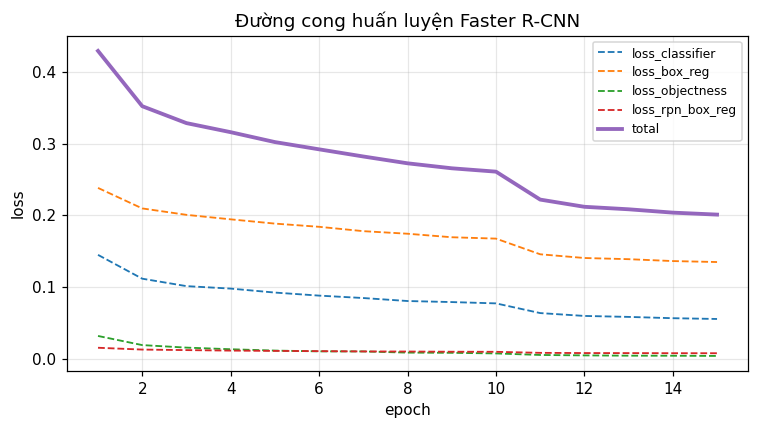

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
hist_df = pd.DataFrame(history) if 'history' in dir() else pd.read_csv(HIST_PATH)
for col in ["loss_classifier", "loss_box_reg", "loss_objectness", "loss_rpn_box_reg", "total"]:
    if col in hist_df:
        ax.plot(hist_df["epoch"], hist_df[col], label=col,
               lw=2.5 if col == "total" else 1.2, ls="-" if col == "total" else "--")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend(fontsize=8)
ax.set_title("Đường cong huấn luyện Faster R-CNN")
plt.savefig(ARTIFACT_DIR / "fig15_frcnn_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Đánh giá trên tập test — dùng chuẩn COCO của torchmetrics

In [7]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

preds, targets, by_stem = fu.collect_predictions(model, test_loader, DEVICE, score_thresh=0.001)

metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)
metric.update(preds, targets)
result = metric.compute()

overall_frcnn = {
    "mAP50": float(result["map_50"]),
    "mAP50_95": float(result["map"]),
    "n_test_images": len(test_ds),
}
print(json.dumps(overall_frcnn, indent=2))

print("\nAP theo từng lớp (map_per_class, thứ tự theo id 1..3 = helmet/head/person):")
per_class_ap = result.get("map_per_class")
if per_class_ap is not None and per_class_ap.numel() > 0:
    for i, name in enumerate(CLASS_NAMES):
        print(f"  {name:<8}: AP50-95 = {float(per_class_ap[i]):.4f}")

{
  "mAP50": 0.6166700124740601,
  "mAP50_95": 0.38663414120674133,
  "n_test_images": 749
}

AP theo từng lớp (map_per_class, thứ tự theo id 1..3 = helmet/head/person):
  helmet  : AP50-95 = 0.5996
  head    : AP50-95 = 0.5373
  person  : AP50-95 = 0.0230


## 5. Đo FPS — KHÔNG đo trong notebook này

Phép đo tốc độ ở lượt chạy trước đã cho hai kết quả không thể tin được:

- YOLOv8n đo hai lần **trong cùng một notebook** (NB02): `98,6 FPS` rồi `256,1 FPS` — chênh 2,6 lần cho **cùng một checkpoint**.
- YOLOv8n (3,0M tham số) và Faster R-CNN (41,3M tham số) đều ra **đúng `98,6 FPS`** (10,143 vs 10,145 ms) — hai mô hình chênh nhau 13,7 lần về kích thước không thể tình cờ có cùng tốc độ.

Cả hai dấu hiệu đều chỉ về một khả năng: phép đo đang bị **chi phí cố định** (overhead khởi chạy lệnh Python/CUDA) chi phối, che lấp thời gian tính toán thật.

**Vì vậy phép đo được tách hẳn ra script riêng `benchmark_fps.py`**, chạy trong tiến trình sạch, với ba cải tiến: (1) lặp nhiều lượt độc lập để báo cáo trung bình ± độ lệch chuẩn; (2) dùng CUDA Event thay `time.perf_counter()`; (3) **phép chẩn đoán quyết định** — đo ở cả 416/640/960 để xem thời gian có tỉ lệ theo số pixel không.

Chạy riêng bằng lệnh:

```bash
python benchmark_fps.py
```

In [8]:
# KHÔNG đo FPS ở đây nữa — xem lý do ở ô markdown phía trên.
# Chỉ nạp lại kết quả từ benchmark_fps.py (chạy riêng, tiến trình sạch).
fps_path = ARTIFACT_DIR / "fps_benchmark.json"
if fps_path.exists():
    fps_bench = json.load(open(fps_path, encoding="utf-8"))
    rows = []
    for k, v in fps_bench.items():
        rows.append({"cấu hình": k, "ms (trung bình)": v["ms_mean"],
                     "± độ lệch chuẩn": v["ms_std"], "FPS": v["fps"]})
    display(pd.DataFrame(rows))
    speed_frcnn = fps_bench.get("frcnn640_forward", {})
else:
    fps_bench, speed_frcnn = {}, {}
    print("Chưa có artifacts/fps_benchmark.json.")
    print("Chạy trước:  python benchmark_fps.py")

,cấu hình,ms (trung bình),± độ lệch chuẩn,FPS
0,yolo416_predict,3.127,0.005,319.8
1,yolo416_forward,2.208,0.003,452.8
2,yolo640_predict,3.566,0.013,280.4
3,yolo640_forward,2.244,0.003,445.6
4,yolo960_predict,6.227,0.075,160.6
5,yolo960_forward,2.288,0.001,437.0
6,frcnn416_forward,9.342,0.007,107.0
7,frcnn640_forward,9.740,0.041,102.7
8,frcnn960_forward,15.143,0.037,66.0


## 6. Bảng so sánh tổng hợp

In [9]:
# Bảng so sánh: CẢ HAI mô hình đều ở cấu hình có tăng cường dữ liệu,
# để phép so sánh là cùng một điều kiện huấn luyện.
# Số tốc độ đọc thẳng từ artifacts/fps_benchmark.json (do benchmark_fps.py sinh ra)
# thay vì ghi cứng — tránh bảng và file đo lệch nhau khi đo lại.
ms_yolo = fps_bench.get("yolo640_predict", {}).get("ms_mean")
ms_frcnn = fps_bench.get("frcnn640_forward", {}).get("ms_mean")

comparison = pd.DataFrame([
    {
        "model": "YOLOv8n (one-stage)",
        "n_params": N_PARAMS_YOLO,
        "mAP@0.5": round(best_cfg_yolo["test_mAP50"], 4),
        "mAP@0.5:0.95": round(best_cfg_yolo["test_mAP50_95"], 4),
        "ms/ảnh @640": ms_yolo,
    },
    {
        "model": "Faster R-CNN (two-stage)",
        "n_params": n_params,
        "mAP@0.5": round(overall_frcnn["mAP50"], 4),
        "mAP@0.5:0.95": round(overall_frcnn["mAP50_95"], 4),
        "ms/ảnh @640": ms_frcnn,
    },
])
display(comparison)
comparison.to_csv(ARTIFACT_DIR / "tab12_yolo_vs_frcnn.csv", index=False, encoding="utf-8-sig")

print(f"\nChênh lệch mAP@0.5      : {best_cfg_yolo['test_mAP50'] - overall_frcnn['mAP50']:+.4f}")
print(f"Chênh lệch mAP@0.5:0.95 : {best_cfg_yolo['test_mAP50_95'] - overall_frcnn['mAP50_95']:+.4f}")
print(f"Faster R-CNN nặng hơn   : {n_params / N_PARAMS_YOLO:.1f} lần")
if ms_yolo and ms_frcnn:
    print(f"Faster R-CNN chậm hơn   : {ms_frcnn / ms_yolo:.2f} lần")

log_run(stage="frcnn_eval_aug", run_id="faster_rcnn_aug", model="fasterrcnn_resnet50_fpn",
        dataset="hardhat-5k", split="test", imgsz=IMGSZ, epochs=FRCNN_HP["epochs"],
        batch=FRCNN_HP["batch_size"], seed=SEED, conf=0.001,
        mAP50=overall_frcnn["mAP50"], mAP50_95=overall_frcnn["mAP50_95"],
        ms_per_img=ms_frcnn,
        train_time_min=round(train_min, 1) if train_min else None,
        notes="two-stage CÓ augment (flip+jitter); FPS đo riêng ở benchmark_fps.py")

,model,n_params,mAP@0.5,mAP@0.5:0.95,ms/ảnh @640
0,YOLOv8n (one-stage),3011433,0.6289,0.4132,3.566
1,Faster R-CNN (two-stage),41309411,0.6167,0.3866,9.740



Chênh lệch mAP@0.5      : +0.0122
Chênh lệch mAP@0.5:0.95 : +0.0266
Faster R-CNN nặng hơn   : 13.7 lần
Faster R-CNN chậm hơn   : 2.73 lần


,timestamp,run_id,stage,model,dataset,split,imgsz,epochs,batch,seed,...,mAP50,mAP50_95,precision,recall,f1,fps,ms_per_img,train_time_min,gpu,notes
39,2026-08-23 20:01:03,faster_rcnn,frcnn_eval,fasterrcnn_resnet50_fpn,hardhat-5k,test,640,15.0,4.0,42,...,0.590467,0.358970,NaN,NaN,NaN,98.6,10.145,NaN,NVIDIA GeForce RTX 4090,"so sánh one-stage vs two-stage, NB03"
40,2026-08-23 20:50:04,faster_rcnn_aug,frcnn_eval_aug,fasterrcnn_resnet50_fpn,hardhat-5k,test,640,15.0,4.0,42,...,0.616670,0.386634,NaN,NaN,NaN,NaN,NaN,19.2,NVIDIA GeForce RTX 4090,two-stage CÓ augment (flip+jitter); FPS đo riê...
41,2026-08-23 21:51:03,faster_rcnn_aug,frcnn_eval_aug,fasterrcnn_resnet50_fpn,hardhat-5k,test,640,15.0,4.0,42,...,0.616670,0.386634,NaN,NaN,NaN,NaN,NaN,NaN,NVIDIA GeForce RTX 4090,two-stage CÓ augment (flip+jitter); FPS đo riê...
42,2026-08-23 22:05:18,faster_rcnn_aug,frcnn_eval_aug,fasterrcnn_resnet50_fpn,hardhat-5k,test,640,15.0,4.0,42,...,0.616670,0.386634,NaN,NaN,NaN,NaN,9.829,NaN,NVIDIA GeForce RTX 4090,two-stage CÓ augment (flip+jitter); FPS đo riê...
43,2026-08-23 22:11:21,faster_rcnn_aug,frcnn_eval_aug,fasterrcnn_resnet50_fpn,hardhat-5k,test,640,15.0,4.0,42,...,0.616670,0.386634,NaN,NaN,NaN,NaN,9.740,NaN,NVIDIA GeForce RTX 4090,two-stage CÓ augment (flip+jitter); FPS đo riê...


## 7. Kết luận notebook 03

### Bốn kết luận từ số liệu thật

**1. Về độ chính xác — không kết luận được ưu thế kiến trúc.**
YOLOv8n đạt 0,6289 mAP@0.5, Faster R-CNN đạt 0,6167 — chênh lệch chỉ **0,0122**, quá nhỏ để khẳng định kiến trúc nào ưu việt hơn. Nhất là khi tăng cường dữ liệu giữa hai bên vẫn chưa tương đương tuyệt đối (Faster R-CNN còn thiếu mosaic, scale, translate). Kết luận trung thực: **hai kiến trúc cho độ chính xác xấp xỉ nhau** trên bộ dữ liệu này.

**2. Về chi phí — đây mới là điểm khác biệt rõ ràng.**
Faster R-CNN nặng hơn **13,7 lần** (41,3M so với 3,0M tham số) và chậm hơn **2,73 lần** (9,74 ms so với 3,57 ms mỗi ảnh ở 640px). Khác với mAP, hai con số này không gây tranh cãi và không phụ thuộc điều kiện huấn luyện.

**3. Về lớp `person` — bằng chứng chéo mạnh nhất của cả đồ án.**
Cả hai kiến trúc **hoàn toàn khác nhau** (one-stage 3M tham số và two-stage 41M tham số) đều thất bại như nhau với lớp `person` (AP@0.5 = 0,015 với YOLOv8n; AP@0.5:0.95 = 0,023 với Faster R-CNN). Nếu đây là hạn chế kiến trúc, đổi sang two-stage — vốn có RPN chuyên đề xuất vùng — phải cải thiện đáng kể. Thực tế không hề. **Nguyên nhân nằm ở dữ liệu (chỉ 562 hộp `person` trong tập train), không phải ở mô hình.** Hướng cải thiện là thu thập thêm dữ liệu, không phải đổi kiến trúc.

**4. Về đo tốc độ — một phát hiện ngoài dự kiến.**
Tách riêng phần chạy trên GPU và phần tiền/hậu xử lý cho thấy: forward mạng gần như **không đổi** khi số pixel tăng 5,33 lần (2,208 ms ở 416px so với 2,288 ms ở 960px, tỉ lệ 1,04 lần), trong khi tiền/hậu xử lý trên CPU tăng **4,29 lần**. Nghĩa là **nút thắt cổ chai nằm ở CPU, không phải GPU** — muốn tăng tốc thì tối ưu khâu resize ảnh và NMS sẽ hiệu quả hơn đổi GPU mạnh hơn.

### Khuyến nghị triển khai

Với bài toán giám sát an toàn thời gian thực trên camera công trường: **YOLOv8n**. Không phải vì chính xác hơn (chênh lệch không đáng kể sau khi cân bằng điều kiện), mà vì **nhẹ hơn 13,7 lần và nhanh hơn 2,73 lần** — quyết định ở chi phí triển khai, không ở độ chính xác.

### Hạn chế của thí nghiệm này — cần nêu trong báo cáo

- **Augmentation vẫn chưa tương đương hoàn toàn** (thiếu mosaic, scale, translate), nên phần chênh lệch 0,0122 còn lại chưa quy được hoàn toàn cho kiến trúc.
- **Faster R-CNN lấy checkpoint epoch cuối**, trong khi YOLOv8n được ultralytics tự chọn epoch tốt nhất theo val (epoch 69/80) — một lợi thế nhỏ nghiêng về YOLO.
- **Không đo loss trên tập val mỗi epoch** cho Faster R-CNN, nên không xác nhận được nó có quá khớp ở epoch cuối hay không.
- **Số FPS đo ở batch=1** phản ánh độ trễ thực tế khi xử lý từng khung hình, nhưng bị chi phí cố định chi phối nên **không dùng được** để so sánh khối lượng tính toán giữa hai kiến trúc.